In [3]:
# %% 1. Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations --quiet
import os, random, warnings, cv2, math, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from albumentations import Compose, Resize, ShiftScaleRotate, RandomBrightnessContrast, GaussianBlur, CoarseDropout, Lambda
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [4]:
# %% 2. Hyper-params & paths
CSV_PATH   = "/content/shape7_labels_all.csv"
IMG_DIR    = "/content/drive/MyDrive/shapes/shape7"
IMG_SIZE   = 128
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 3e-4
PATIENCE   = 10
TOL        = 1   # ±1 tolerance for accuracy

In [5]:
# %% 3. Smart auto-crop
def smart_center_crop(img: np.ndarray, thr=20):
    ys, xs = np.where(img > thr)
    if xs.size == 0: return img
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    side = max(x1 - x0, y1 - y0) + 2
    cx, cy = (x0 + x1)//2, (y0 + y1)//2
    half = side//2
    x0, x1, y0, y1 = cx-half, cx+half, cy-half, cy+half
    pad_x0, pad_y0 = max(-x0,0), max(-y0,0)
    pad_x1, pad_y1 = max(x1-img.shape[1]+1,0), max(y1-img.shape[0]+1,0)
    if pad_x0+pad_x1+pad_y0+pad_y1:
        img = np.pad(img, ((pad_y0,pad_y1),(pad_x0,pad_x1)), constant_values=0)
        y0+=pad_y0; y1+=pad_y0; x0+=pad_x0; x1+=pad_x0
    return img[y0:y1+1, x0:x1+1]

class SmartCrop:
    def __init__(self, thr=20): self.thr=thr
    def __call__(self, img, **kw): return smart_center_crop(img, self.thr)


In [6]:
# %% 4. Dataset & transforms
train_tf = Compose([
    Lambda(image=SmartCrop(20)),
    Resize(IMG_SIZE, IMG_SIZE),
    ShiftScaleRotate(0.05, 0.05, 10, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),
    RandomBrightnessContrast(0.2, 0.2, p=0.5),
    GaussianBlur(blur_limit=3, p=0.3),
    CoarseDropout(
        max_holes=4,
        max_height=16,
        max_width=16,
        min_holes=1,
        min_height=8,
        min_width=8,
        fill_value=0,
        p=0.3
    ),
    ToTensorV2()
])
val_tf = Compose([
    Lambda(image=SmartCrop(20)),
    Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2()
])

class ShapeDataset(Dataset):
    def __init__(self, df, img_dir, tf):
        self.df, self.dir, self.tf = df.reset_index(drop=True), img_dir, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.dir, f"{row.child_id}.png"), cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((200,200),np.uint8)
        img = self.tf(image=img)["image"].float()/255.0
        return img, torch.tensor(row.label, dtype=torch.float32)


In [7]:
# %% 5. Model
class ResNet18Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features,1)
    def forward(self,x): return self.backbone(x).squeeze(1)


In [8]:

# %% 6. Metrics
mae = lambda p,t: torch.mean(torch.abs(p-t)).item()
def acc_std(p,t): return (torch.round(p).int()==t.int()).float().mean().item()*100
def acc_tol(p,t, tol=TOL): return (torch.abs(torch.round(p)-t)<=tol).float().mean().item()*100


In [11]:
# %% 7. Train one fold
from tqdm.notebook import tqdm

def run_fold(train_idx, val_idx, full_df, fold_id):
    train_df, val_df = full_df.iloc[train_idx], full_df.iloc[val_idx]
    counts = train_df.label.value_counts().sort_index().values
    w = 1.0/(counts+1e-6)
    samp_w = train_df.label.apply(lambda l: w[int(l)-1]).values
    sampler = WeightedRandomSampler(samp_w, len(samp_w), True)
    train_loader = DataLoader(ShapeDataset(train_df, IMG_DIR, train_tf), BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader   = DataLoader(ShapeDataset(val_df,   IMG_DIR, val_tf),   BATCH_SIZE, shuffle=False, num_workers=2)

    model = ResNet18Reg().to(device)
    for n,p in model.backbone.named_parameters():
        p.requires_grad = n.startswith("layer4") or n.startswith("fc")
    opt = optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()), lr=LR)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=3, min_lr=1e-6, verbose=False)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    best_mae, patience = 1e9, 0
    train_losses, val_maes = [], []

    for epoch in range(1, EPOCHS+1):
        model.train()
        epoch_loss = 0.0
        for x,y in tqdm(train_loader, desc=f"Fold {fold_id} | Epoch {epoch}/{EPOCHS}", leave=False):
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * x.size(0)

        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval(); pv, tv = [], []
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                pv.append(model(x).cpu()); tv.append(y.cpu())
        pv, tv = torch.cat(pv), torch.cat(tv)
        v_mae = mae(pv,tv)
        val_maes.append(v_mae)
        sch.step(v_mae)

        print(f"Epoch {epoch:2d} | Train Loss: {epoch_loss:.4f} | Val MAE: {v_mae:.4f} | Patience: {patience}")

        if v_mae < best_mae - 1e-3:
            best_mae, patience = v_mae, 0
            torch.save(model.state_dict(), f"/content/best_fold{fold_id}.pth")
        else:
            patience += 1
            if patience >= PATIENCE: break

    # Reload best
    model.load_state_dict(torch.load(f"/content/best_fold{fold_id}.pth", map_location=device))
    model.eval(); pv, tv = [], []
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            pv.append(model(x).cpu()); tv.append(y.cpu())
    pv, tv = torch.cat(pv), torch.cat(tv)

    # Store per-fold logs
    model._train_logs = {'train_loss': train_losses, 'val_mae': val_maes, 'val_targets': tv, 'val_preds': pv}

    return mae(pv,tv), acc_std(pv,tv), acc_tol(pv,tv), model


In [12]:
# %% 8. 5-fold CV
df = pd.read_csv(CSV_PATH)
df = df[df.child_id.apply(lambda cid: os.path.exists(os.path.join(IMG_DIR,f"{cid}.png")))].reset_index(drop=True)
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)

mae_list, std_list, tol_list = [],[],[]
fold_models = []
for fold, (tr,va) in enumerate(skf.split(df, df.label),1):
    m,s,t,model = run_fold(tr,va,df,fold)
    mae_list.append(m); std_list.append(s); tol_list.append(t); fold_models.append(model)
    print(f"Fold{fold}: MAE {m:.3f} | ±0 {s:.1f}% | ±{TOL} {t:.1f}%")
print(f"\n5-fold avg MAE {np.mean(mae_list):.3f}±{np.std(mae_list):.3f}")
print(f"5-fold avg ±0 {np.mean(std_list):.1f}% | ±{TOL} {np.mean(tol_list):.1f}%")

best_model = fold_models[np.argmin(mae_list)]


Fold 1 | Epoch 1/60:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 1.6548 | Val MAE: 1.4122 | Patience: 0


Fold 1 | Epoch 2/60:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.8008 | Val MAE: 0.9393 | Patience: 0


Fold 1 | Epoch 3/60:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 27 | Train Loss: 0.3562 | Val MAE: 0.7547 | Patience: 7


Fold 5 | Epoch 28/60:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 28 | Train Loss: 0.3599 | Val MAE: 0.7647 | Patience: 8


Fold 5 | Epoch 29/60:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 29 | Train Loss: 0.3592 | Val MAE: 0.7269 | Patience: 9
Fold5: MAE 0.713 | ±0 45.5% | ±1 91.0%

5-fold avg MAE 0.672±0.039
5-fold avg ±0 47.8% | ±1 91.7%


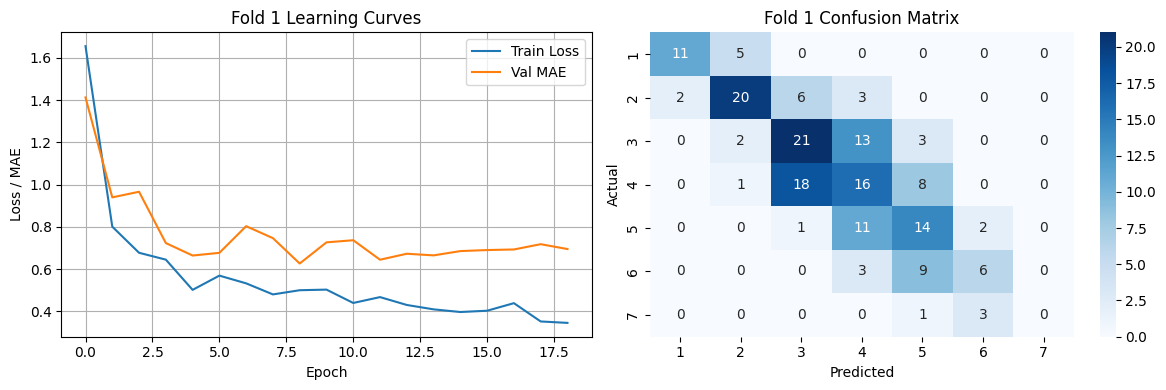

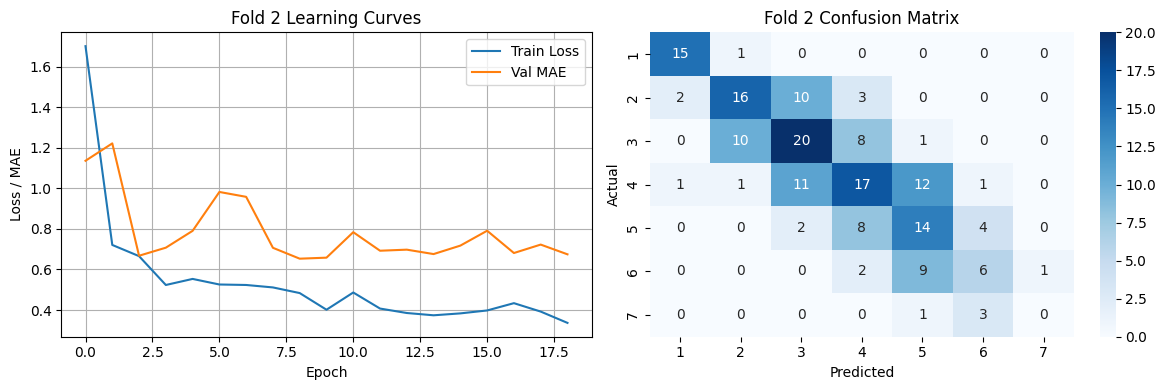

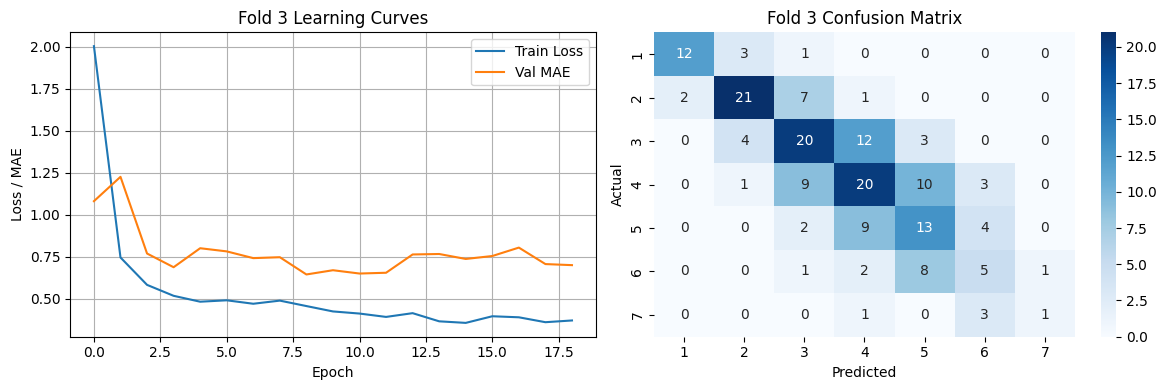

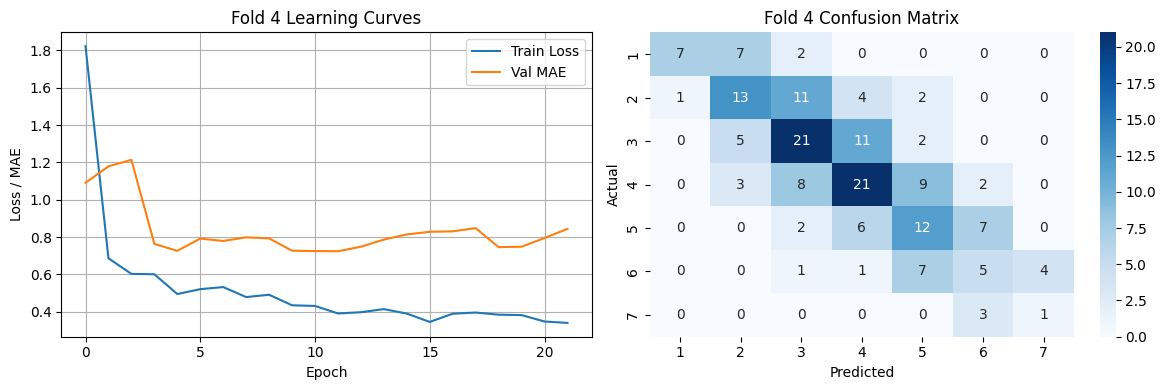

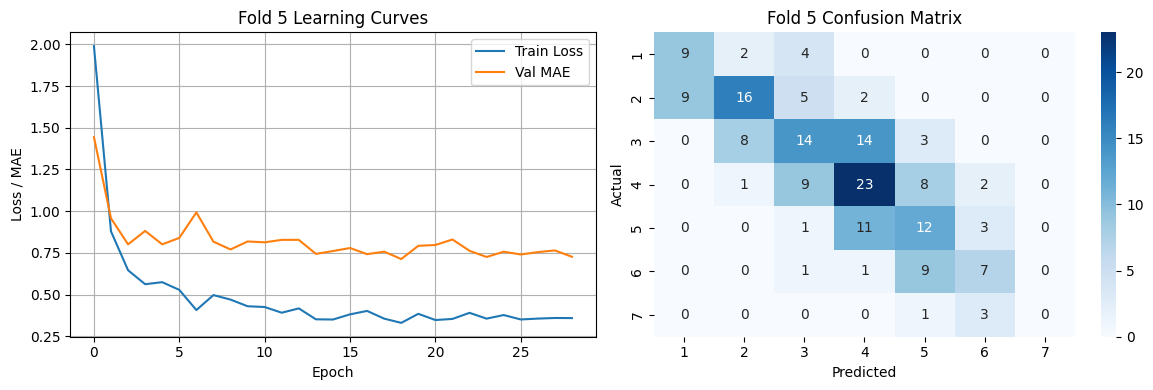

In [13]:
# %% 9. Analyze training: learning curves & confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_fold_analysis(model, fold_id):
    logs = model._train_logs
    train_loss, val_mae = logs['train_loss'], logs['val_mae']
    pv, tv = logs['val_preds'], logs['val_targets']

    # Plot learning curves
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_mae, label="Val MAE")
    plt.title(f"Fold {fold_id} Learning Curves")
    plt.xlabel("Epoch"); plt.ylabel("Loss / MAE")
    plt.legend(); plt.grid(True)

    # Confusion Matrix with ±1 tolerance
    pred_rounded = pv.numpy().round().clip(1,7).astype(int)
    true_labels  = tv.numpy().round().astype(int)
    cm = confusion_matrix(true_labels, pred_rounded, labels=[1,2,3,4,5,6,7])

    plt.subplot(1,2,2)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1,8), yticklabels=range(1,8))
    plt.title(f"Fold {fold_id} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Plot for each fold
for i, model in enumerate(fold_models, 1):
    plot_fold_analysis(model, i)

In [16]:
# %% 9. Grad-CAM utils
def grad_cam(model, x, tgt_layer):
    acts, grads = [], []
    def fwd(m, i, o): acts.append(o)
    def bwd(m, gi, go): grads.append(go[0])
    h1 = tgt_layer.register_forward_hook(fwd)
    h2 = tgt_layer.register_backward_hook(bwd)
    model.zero_grad()
    out = model(x)
    out.backward(torch.ones_like(out))
    a, g = acts[0].squeeze(0), grads[0].squeeze(0)
    w = g.mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * a).sum(0))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    h1.remove(); h2.remove()
    return cam.detach().cpu().numpy()

def show_heat(img_t, cam):
    img = img_t.squeeze().cpu().numpy()
    cam = cv2.resize(cam, img.shape[::-1])
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (0.5 * heat + np.stack([img * 255] * 3, 2)).astype(np.uint8)

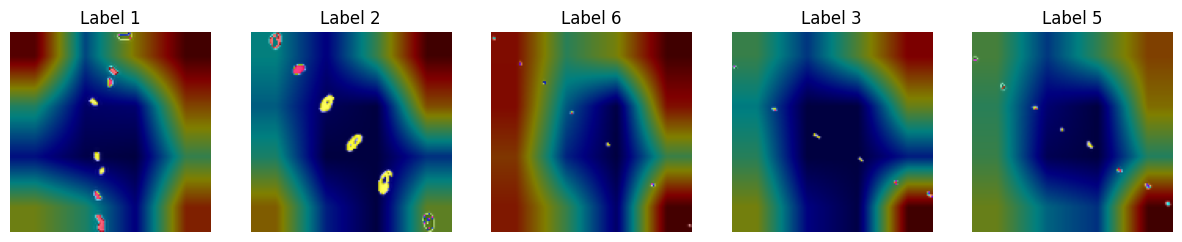

In [17]:
# %% 10. Grad-CAM demo on 5 images
sampled = df.groupby('label').head(1).sample(5, random_state=SEED)
ds = ShapeDataset(sampled, IMG_DIR, val_tf)
tgt_layer = best_model.backbone.layer4
plt.figure(figsize=(15,4))
for i,(img,label) in enumerate(ds):
    x = img.unsqueeze(0).to(device)
    cam = grad_cam(best_model,x,tgt_layer)
    vis = show_heat(img, cam)
    plt.subplot(1,5,i+1); plt.imshow(vis); plt.title(f"Label {int(label.item())}"); plt.axis('off')
plt.show()